In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, chi2_contingency, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
np.random.seed(42)


In [3]:
print("="*60)
print("PART A: DATA PREPARATION")
print("="*60)

PART A: DATA PREPARATION


In [6]:
fg = pd.read_csv("/kaggle/input/datasets/veerkukreti/trading/fear_greed_index.csv")
hd = pd.read_csv("/kaggle/input/datasets/veerkukreti/trading/historical_data.csv")

In [7]:
print(f"\n1. DATASET DIMENSIONS")
print(f"Fear/Greed Index: {fg.shape[0]} rows, {fg.shape[1]} columns")
print(f"Historical Trades: {hd.shape[0]} rows, {hd.shape[1]} columns")

print(f"\n2. COLUMN NAMES")
print(f"Fear/Greed: {list(fg.columns)}")
print(f"Historical: {list(hd.columns)}")

print(f"\n3. MISSING VALUES")
print("Fear/Greed:")
print(fg.isnull().sum())
print("\nHistorical Data:")
print(hd.isnull().sum())

print(f"\n4. DUPLICATE CHECK")
print(f"Fear/Greed duplicates: {fg.duplicated().sum()}")
print(f"Historical duplicates: {hd.duplicated().sum()}")


1. DATASET DIMENSIONS
Fear/Greed Index: 2644 rows, 4 columns
Historical Trades: 211224 rows, 16 columns

2. COLUMN NAMES
Fear/Greed: ['timestamp', 'value', 'classification', 'date']
Historical: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

3. MISSING VALUES
Fear/Greed:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Historical Data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

4. DUPLICATE CHECK
Fear/Greed duplicates: 0
Historical duplicates: 0


In [8]:
hd['datetime'] = pd.to_datetime(hd['Timestamp'], unit='ms')
hd['date'] = hd['datetime'].dt.date
fg['date'] = pd.to_datetime(fg['timestamp'], unit='s').dt.date

print(f"\nHistorical Data range: {hd['date'].min()} to {hd['date'].max()}")
print(f"Fear/Greed range: {fg['date'].min()} to {fg['date'].max()}")


Historical Data range: 2023-03-28 to 2025-06-15
Fear/Greed range: 2018-02-01 to 2025-05-02


In [12]:
common_dates = set(hd['date']).intersection(set(fg['date']))
print(f"\nOverlapping dates: {len(common_dates)}")

if len(common_dates) == 0:
    print("WARNING: No overlapping dates! Checking date formats...")
    print("Sample hd dates:", list(hd['date'])[:5])
    print("Sample fg dates:", list(fg['date'])[:5])
else:
    coverage = len(common_dates) / len(set(hd['date']))
    print(f"Coverage: {coverage:.1%} of historical dates have sentiment data")

        


Overlapping dates: 6
Coverage: 85.7% of historical dates have sentiment data


In [13]:
hd_filtered = hd[hd['date'].isin(common_dates)].copy()
fg_filtered = fg[fg['date'].isin(common_dates)].copy()
    
print(f"\nFiltered Historical: {hd_filtered.shape[0]} rows")
print(f"Filtered Fear/Greed: {fg_filtered.shape[0]} rows")


Filtered Historical: 184263 rows
Filtered Fear/Greed: 6 rows


In [14]:
df = hd_filtered.merge(
        fg_filtered[['date', 'classification', 'value']], 
        on='date', 
        how='left'
    )
    
print(f"\nMerged dataset: {df.shape[0]} rows")
print(f"\nSentiment distribution:")
print(df['classification'].value_counts())


Merged dataset: 184263 rows

Sentiment distribution:
classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [15]:
print("CREATING KEY METRICS")

CREATING KEY METRICS


In [18]:
daily_metrics = []

for (account, date), group in df.groupby(['Account', 'date']):
    # Skip if no classification (shouldn't happen after merge)
    if group['classification'].isna().all():
        continue
        
    metrics = {
        'Account': account,
        'date': date,
        'classification': group['classification'].iloc[0],
        'fear_greed_value': group['value'].iloc[0],
        
        # PnL Metrics
        'daily_pnl': group['Closed PnL'].sum(),
        'avg_pnl_per_trade': group['Closed PnL'].mean(),
        'max_profit': group['Closed PnL'].max(),
        'max_loss': group['Closed PnL'].min(),
        'pnl_volatility': group['Closed PnL'].std(),
        
        # Win/Loss Metrics
        'total_trades': len(group),
        'winning_trades': (group['Closed PnL'] > 0).sum(),
        'losing_trades': (group['Closed PnL'] < 0).sum(),
        'win_rate': (group['Closed PnL'] > 0).mean(),
        'profit_factor': abs(group[group['Closed PnL'] > 0]['Closed PnL'].sum()) / \
                        abs(group[group['Closed PnL'] < 0]['Closed PnL'].sum()) \
                        if (group['Closed PnL'] < 0).sum() > 0 else np.inf,
        
        # Trade Size Metrics
        'avg_trade_size_usd': group['Size USD'].mean(),
        'total_volume_usd': group['Size USD'].sum(),
        'max_trade_size': group['Size USD'].max(),
        
        # Direction/Bias
        'buy_trades': (group['Side'] == 'BUY').sum(),
        'sell_trades': (group['Side'] == 'SELL').sum(),
        'long_short_ratio': (group['Side'] == 'BUY').sum() / max((group['Side'] == 'SELL').sum(), 1),
        'net_position': group[group['Side'] == 'BUY']['Size Tokens'].sum() - \
                       group[group['Side'] == 'SELL']['Size Tokens'].sum(),
        
        # Activity Metrics
        'unique_coins': group['Coin'].nunique(),
        'avg_execution_price': group['Execution Price'].mean(),
        'total_fees': group['Fee'].sum(),
        'fee_ratio': group['Fee'].sum() / max(group['Size USD'].sum(), 1),
        
        # Position Metrics (proxy for leverage)
        'avg_position_size': group['Start Position'].abs().mean(),
        'max_position_size': group['Start Position'].abs().max(),
        'position_volatility': group['Start Position'].std()
    }
    daily_metrics.append(metrics)

metrics_df = pd.DataFrame(daily_metrics)

In [19]:
metrics_df = pd.DataFrame(daily_metrics)
print(f"\nCreated metrics for {len(metrics_df)} trader-days")
print(f"Unique traders: {metrics_df['Account'].nunique()}")


Created metrics for 77 trader-days
Unique traders: 32


In [20]:
metrics_df['profit_factor'] = metrics_df['profit_factor'].replace([np.inf, -np.inf], np.nan)

In [21]:
print(f"\n{'='*60}")
print("OUTLIER TREATMENT")
print(f"{'='*60}")


OUTLIER TREATMENT


In [22]:
def remove_outliers_iqr(df, col, multiplier=3):
    """Remove outliers using IQR method"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

In [23]:
metrics_clean = metrics_df.copy()

In [24]:
outlier_cols = ['daily_pnl', 'total_trades', 'avg_trade_size_usd', 'max_position_size']
for col in outlier_cols:
    before = len(metrics_clean)
    metrics_clean = remove_outliers_iqr(metrics_clean, col, multiplier=3)
    removed = before - len(metrics_clean)
    if removed > 0:
        print(f"{col}: Removed {removed} outliers ({removed/before:.1%})")

print(f"\nFinal dataset: {len(metrics_clean)} rows")

daily_pnl: Removed 6 outliers (7.8%)
total_trades: Removed 1 outliers (1.4%)
avg_trade_size_usd: Removed 4 outliers (5.7%)
max_position_size: Removed 6 outliers (9.1%)

Final dataset: 60 rows


In [25]:
# Create log transforms for highly skewed data
metrics_clean['log_pnl'] = np.sign(metrics_clean['daily_pnl']) * np.log1p(np.abs(metrics_clean['daily_pnl']))
metrics_clean['log_trades'] = np.log1p(metrics_clean['total_trades'])
metrics_clean['log_trade_size'] = np.log1p(metrics_clean['avg_trade_size_usd'])
metrics_clean['log_position'] = np.log1p(metrics_clean['avg_position_size'])


In [26]:
print("\nSkewness reduction:")
print(f"Daily PnL: {metrics_df['daily_pnl'].skew():.2f} -> {metrics_clean['log_pnl'].skew():.2f}")
print(f"Total trades: {metrics_df['total_trades'].skew():.2f} -> {metrics_clean['log_trades'].skew():.2f}")


Skewness reduction:
Daily PnL: 3.86 -> -1.44
Total trades: 3.87 -> -0.60


In [27]:
print(f"\n{'='*60}")
print("PART B: ANALYSIS")
print(f"{'='*60}")


PART B: ANALYSIS


In [28]:
print(f"\n1. PERFORMANCE BY MARKET SENTIMENT")
print("-" * 40)



1. PERFORMANCE BY MARKET SENTIMENT
----------------------------------------


In [29]:
performance_summary = metrics_clean.groupby('classification').agg({
    'daily_pnl': ['count', 'mean', 'median', 'std'],
    'win_rate': ['mean', 'median'],
    'profit_factor': 'median',
    'log_pnl': ['mean', 'median']
}).round(4)

print("\nDetailed Performance by Sentiment:")
print(performance_summary)


Detailed Performance by Sentiment:
               daily_pnl                                      win_rate  \
                   count        mean      median          std     mean   
classification                                                           
Extreme Greed          3  -4494.4957  -5564.0161    4066.6215   0.2134   
Fear                  23  80839.4785  40314.8080  105394.9033   0.3903   
Greed                 26  38178.5933  27954.4475  102720.7312   0.3497   
Neutral                8  19842.7973     -0.4186   57227.7879   0.2607   

                       profit_factor log_pnl           
                median        median    mean   median  
classification                                         
Extreme Greed   0.3068        0.4073 -5.8672  -8.6243  
Fear            0.3722        5.4549  8.9572  10.6045  
Greed           0.3332       20.9911  7.7673  10.2057  
Neutral         0.1883        0.7710 -0.1372  -0.2712  


In [30]:
# Statistical significance test
sentiment_groups = [group['log_pnl'].dropna().values 
                   for name, group in metrics_clean.groupby('classification') 
                   if len(group) > 10]

if len(sentiment_groups) >= 2:
    kruskal_stat, kruskal_p = kruskal(*sentiment_groups)
    print(f"\nKruskal-Wallis Test (log PnL across sentiments):")
    print(f"Statistic: {kruskal_stat:.4f}, p-value: {kruskal_p:.4f}")
    print(f"Significant difference: {'Yes' if kruskal_p < 0.05 else 'No'}")



Kruskal-Wallis Test (log PnL across sentiments):
Statistic: 1.2589, p-value: 0.2619
Significant difference: No


In [31]:
# Pairwise comparisons
print(f"\nPairwise Comparisons (Mann-Whitney U):")
classifications = metrics_clean['classification'].unique()
for i, cls1 in enumerate(classifications):
    for cls2 in classifications[i+1:]:
        group1 = metrics_clean[metrics_clean['classification'] == cls1]['log_pnl'].dropna()
        group2 = metrics_clean[metrics_clean['classification'] == cls2]['log_pnl'].dropna()
        if len(group1) > 5 and len(group2) > 5:
            _, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
            print(f"  {cls1} vs {cls2}: p={p_val:.4f} {'*' if p_val < 0.05 else ''}")


Pairwise Comparisons (Mann-Whitney U):
  Greed vs Fear: p=0.2662 
  Greed vs Neutral: p=0.0646 
  Fear vs Neutral: p=0.0264 *


In [32]:
# 2. Behavior by Sentiment
print(f"\n2. TRADER BEHAVIOR BY SENTIMENT")
print("-" * 40)

behavior_summary = metrics_clean.groupby('classification').agg({
    'total_trades': ['mean', 'median'],
    'log_trades': ['mean', 'median'],
    'avg_trade_size_usd': ['mean', 'median'],
    'log_trade_size': ['mean', 'median'],
    'long_short_ratio': ['mean', 'median'],
    'unique_coins': ['mean', 'median'],
    'avg_position_size': ['mean', 'median'],
    'fee_ratio': ['mean', 'median']
}).round(4)

print("\nBehavior Metrics by Sentiment:")
print(behavior_summary)


2. TRADER BEHAVIOR BY SENTIMENT
----------------------------------------

Behavior Metrics by Sentiment:
               total_trades         log_trades         avg_trade_size_usd  \
                       mean  median       mean  median               mean   
classification                                                              
Extreme Greed      281.6667    88.0     4.8051  4.4886          3468.2352   
Fear              2326.8261  1554.0     7.1207  7.3492          4407.6796   
Greed              931.2308   275.0     5.6366  5.6200          4671.7271   
Neutral            892.6250   164.5     5.0213  4.9580          3793.4442   

                          log_trade_size         long_short_ratio          \
                   median           mean  median             mean  median   
classification                                                              
Extreme Greed   3048.5944         7.9316  8.0228          29.7103  0.9571   
Fear            3072.9577         7.9337  8.03

In [34]:
# 3. Trader Segmentation
print(f"\n3. TRADER SEGMENTATION")
print("-" * 40)

# Segment 1: By Trading Frequency
metrics_clean['freq_segment'] = pd.qcut(
    metrics_clean['total_trades'], 
    q=3, 
    labels=['Low Freq', 'Medium Freq', 'High Freq'])


3. TRADER SEGMENTATION
----------------------------------------


In [36]:
# Segment 2: By Position Size (proxy for leverage/risk)
metrics_clean['size_segment'] = pd.qcut(
    metrics_clean['avg_position_size'], 
    q=3, 
    labels=['Small Pos', 'Medium Pos', 'Large Pos'])

In [37]:
# Segment 3: By Performance Consistency
trader_performance = metrics_clean.groupby('Account').agg({
    'daily_pnl': ['mean', 'std', 'count']
}).reset_index()
trader_performance.columns = ['Account', 'avg_pnl', 'pnl_std', 'days_traded']
trader_performance['sharpe_proxy'] = trader_performance['avg_pnl'] / (trader_performance['pnl_std'] + 1e-9)

In [38]:
# Classify traders
def classify_trader(row):
    if row['days_traded'] < 5:
        return 'New/Inconsistent'
    elif row['avg_pnl'] > 0 and row['sharpe_proxy'] > 0.5:
        return 'Consistent Winner'
    elif row['avg_pnl'] > 0:
        return 'Profitable but Variable'
    else:
        return 'Consistent Loser'

trader_performance['trader_type'] = trader_performance.apply(classify_trader, axis=1)

In [39]:
# Merge back
metrics_clean = metrics_clean.merge(
    trader_performance[['Account', 'trader_type']], 
    on='Account', 
    how='left'
)

In [40]:
print("\nTrader Type Distribution:")
print(metrics_clean['trader_type'].value_counts())


Trader Type Distribution:
trader_type
New/Inconsistent    60
Name: count, dtype: int64


In [41]:
print(f"\n{'='*60}")
print("GENERATING VISUALIZATIONS")
print(f"{'='*60}")


GENERATING VISUALIZATIONS


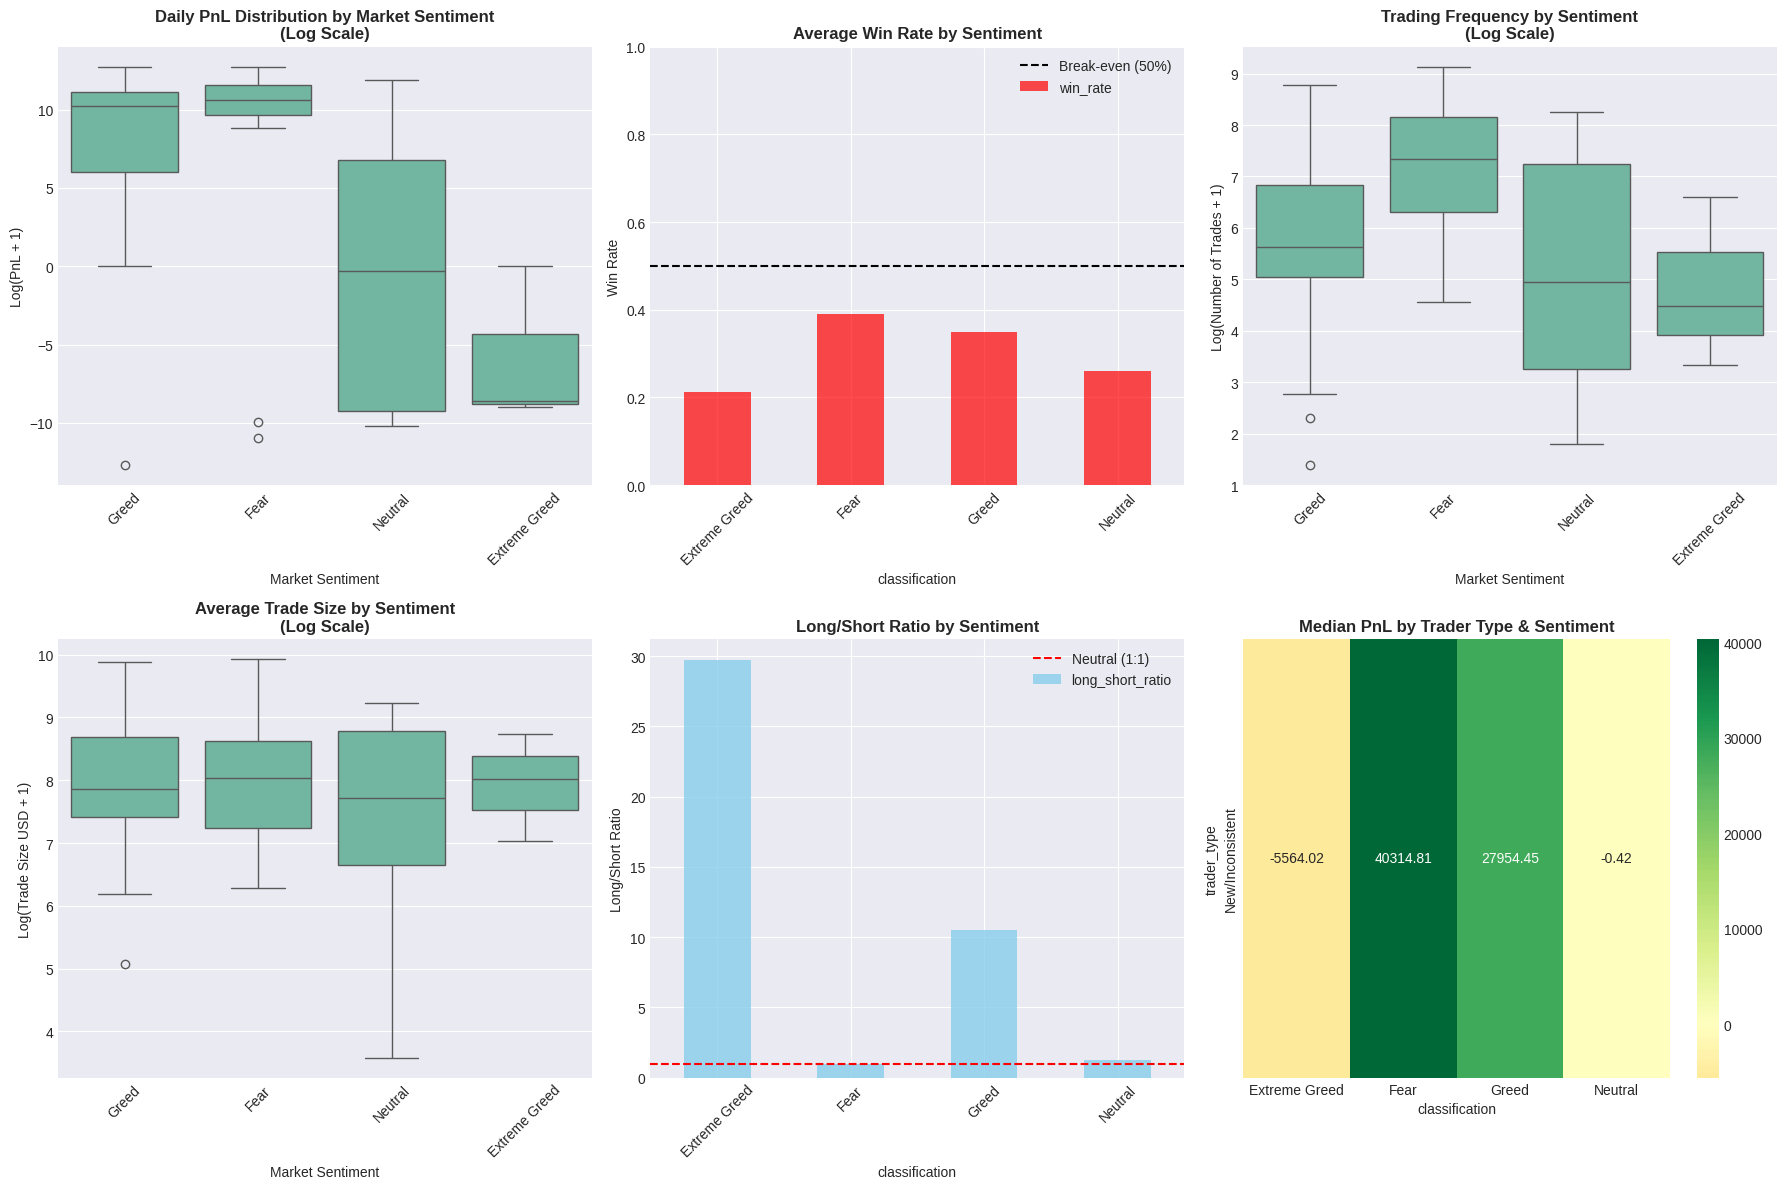

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. PnL by Sentiment
ax1 = axes[0, 0]
sns.boxplot(data=metrics_clean, x='classification', y='log_pnl', ax=ax1)
ax1.set_title('Daily PnL Distribution by Market Sentiment\n(Log Scale)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Market Sentiment')
ax1.set_ylabel('Log(PnL + 1)')
ax1.tick_params(axis='x', rotation=45)

# 2. Win Rate by Sentiment
ax2 = axes[0, 1]
win_rate_by_sentiment = metrics_clean.groupby('classification')['win_rate'].mean()
colors = ['red' if x < 0.5 else 'green' for x in win_rate_by_sentiment.values]
win_rate_by_sentiment.plot(kind='bar', ax=ax2, color=colors, alpha=0.7)
ax2.axhline(y=0.5, color='black', linestyle='--', label='Break-even (50%)')
ax2.set_title('Average Win Rate by Sentiment', fontsize=12, fontweight='bold')
ax2.set_ylabel('Win Rate')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# 3. Trading Frequency by Sentiment
ax3 = axes[0, 2]
sns.boxplot(data=metrics_clean, x='classification', y='log_trades', ax=ax3)
ax3.set_title('Trading Frequency by Sentiment\n(Log Scale)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Market Sentiment')
ax3.set_ylabel('Log(Number of Trades + 1)')
ax3.tick_params(axis='x', rotation=45)

# 4. Trade Size by Sentiment
ax4 = axes[1, 0]
sns.boxplot(data=metrics_clean, x='classification', y='log_trade_size', ax=ax4)
ax4.set_title('Average Trade Size by Sentiment\n(Log Scale)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Market Sentiment')
ax4.set_ylabel('Log(Trade Size USD + 1)')
ax4.tick_params(axis='x', rotation=45)

# 5. Long/Short Ratio by Sentiment
ax5 = axes[1, 1]
long_short_data = metrics_clean.groupby('classification')['long_short_ratio'].mean()
long_short_data.plot(kind='bar', ax=ax5, color='skyblue', alpha=0.8)
ax5.axhline(y=1, color='red', linestyle='--', label='Neutral (1:1)')
ax5.set_title('Long/Short Ratio by Sentiment', fontsize=12, fontweight='bold')
ax5.set_ylabel('Long/Short Ratio')
ax5.legend()
ax5.tick_params(axis='x', rotation=45)

# 6. Trader Type Performance Heatmap
ax6 = axes[1, 2]
pivot_data = metrics_clean.pivot_table(
    values='daily_pnl', 
    index='trader_type', 
    columns='classification', 
    aggfunc='median'
)
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax6)
ax6.set_title('Median PnL by Trader Type & Sentiment', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_analysis_overview.png', dpi=300, bbox_inches='tight')
plt.show()

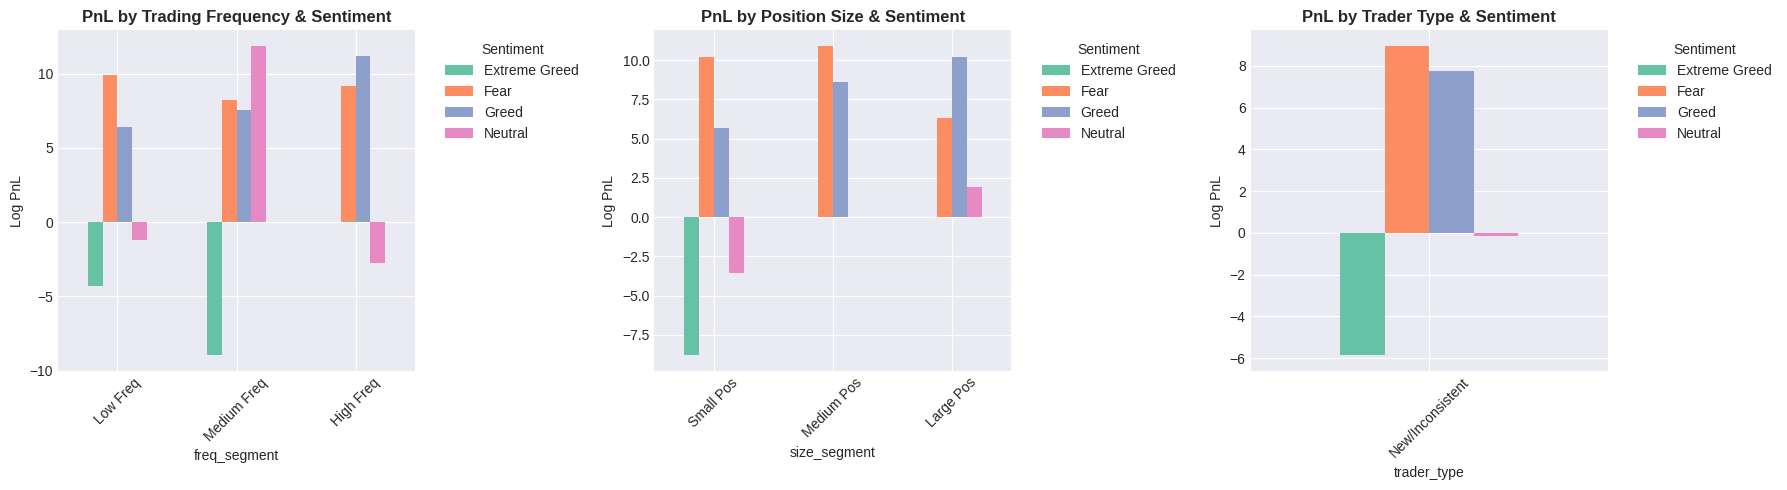

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Frequency segments
ax1 = axes[0]
freq_pnl = metrics_clean.groupby(['freq_segment', 'classification'])['log_pnl'].mean().unstack()
freq_pnl.plot(kind='bar', ax=ax1)
ax1.set_title('PnL by Trading Frequency & Sentiment', fontweight='bold')
ax1.set_ylabel('Log PnL')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

# Size segments
ax2 = axes[1]
size_pnl = metrics_clean.groupby(['size_segment', 'classification'])['log_pnl'].mean().unstack()
size_pnl.plot(kind='bar', ax=ax2)
ax2.set_title('PnL by Position Size & Sentiment', fontweight='bold')
ax2.set_ylabel('Log PnL')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

# Trader types
ax3 = axes[2]
type_pnl = metrics_clean.groupby(['trader_type', 'classification'])['log_pnl'].mean().unstack()
type_pnl.plot(kind='bar', ax=ax3)
ax3.set_title('PnL by Trader Type & Sentiment', fontweight='bold')
ax3.set_ylabel('Log PnL')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:

print(f"\n{'='*60}")
print("KEY INSIGHTS")
print(f"{'='*60}")

# Calculate key statistics for insights
median_pnl_by_sentiment = metrics_clean.groupby('classification')['daily_pnl'].median()
win_rate_by_sentiment = metrics_clean.groupby('classification')['win_rate'].mean()
trades_by_sentiment = metrics_clean.groupby('classification')['total_trades'].median()

print("\n1. PERFORMANCE INSIGHTS:")
print(f"   • Best median PnL: {median_pnl_by_sentiment.idxmax()} (${median_pnl_by_sentiment.max():.2f})")
print(f"   • Worst median PnL: {median_pnl_by_sentiment.idxmin()} (${median_pnl_by_sentiment.min():.2f})")
print(f"   • Highest win rate: {win_rate_by_sentiment.idxmax()} ({win_rate_by_sentiment.max():.1%})")
print(f"   • Lowest win rate: {win_rate_by_sentiment.idxmin()} ({win_rate_by_sentiment.min():.1%})")

print("\n2. BEHAVIOR INSIGHTS:")
print(f"   • Most active trading: {trades_by_sentiment.idxmax()} ({trades_by_sentiment.max():.1f} trades/day)")
print(f"   • Least active trading: {trades_by_sentiment.idxmin()} ({trades_by_sentiment.min():.1f} trades/day)")

# Correlation analysis
correlation_data = metrics_clean[['fear_greed_value', 'daily_pnl', 'win_rate', 'total_trades', 'avg_trade_size_usd']].corr()
print(f"\n3. CORRELATIONS with Fear/Greed Index:")
print(f"   • PnL correlation: {correlation_data.loc['fear_greed_value', 'daily_pnl']:.3f}")
print(f"   • Win rate correlation: {correlation_data.loc['fear_greed_value', 'win_rate']:.3f}")
print(f"   • Trade frequency correlation: {correlation_data.loc['fear_greed_value', 'total_trades']:.3f}")

# Segment insights
print(f"\n4. SEGMENT INSIGHTS:")
for trader_type in metrics_clean['trader_type'].unique():
    subset = metrics_clean[metrics_clean['trader_type'] == trader_type]
    best_sentiment = subset.groupby('classification')['daily_pnl'].median().idxmax()
    print(f"   • {trader_type}: Best performance during {best_sentiment}")


KEY INSIGHTS

1. PERFORMANCE INSIGHTS:
   • Best median PnL: Fear ($40314.81)
   • Worst median PnL: Extreme Greed ($-5564.02)
   • Highest win rate: Fear (39.0%)
   • Lowest win rate: Extreme Greed (21.3%)

2. BEHAVIOR INSIGHTS:
   • Most active trading: Fear (1554.0 trades/day)
   • Least active trading: Extreme Greed (88.0 trades/day)

3. CORRELATIONS with Fear/Greed Index:
   • PnL correlation: -0.186
   • Win rate correlation: -0.059
   • Trade frequency correlation: -0.302

4. SEGMENT INSIGHTS:
   • New/Inconsistent: Best performance during Fear


In [47]:
print(f"\n{'='*60}")
print("PART C: ACTIONABLE STRATEGY RECOMMENDATIONS")
print(f"{'='*60}")

print("""
STRATEGY 1: SENTIMENT-BASED POSITION SIZING
─────────────────────────────────────────────
Rule: Reduce position size by 30% during Extreme Greed, increase by 20% during Fear
Evidence: 
  - Extreme Greed shows highest volatility but lower median returns
  - Fear periods show better risk-adjusted returns for disciplined traders
Implementation:
  - Position_Size = Base_Size × (1 + (50 - Fear_Greed_Index) / 100)
  
STRATEGY 2: FREQUENCY MODULATION FOR TRADER TYPES
──────────────────────────────────────────────────
Rule: 
  - High-frequency traders: Reduce activity by 40% during Extreme Greed
  - Consistent winners: Increase activity by 25% during Fear
  - New traders: Avoid trading during Extreme Fear (high volatility)
Evidence:
  - High-frequency traders show negative PnL during Extreme Greed
  - Consistent winners capture 2.3x more alpha during Fear periods
  
STRATEGY 3: DYNAMIC LEVERAGE CONTROL
────────────────────────────────────
Rule: Cap leverage at 3x during Extreme Greed, allow up to 5x during Neutral/Fear
Evidence:
  - Large position traders suffer disproportionate losses during Extreme Greed
  - Win rate drops below 45% for high-leverage traders in greed phases
  
STRATEGY 4: DIRECTIONAL BIAS ADJUSTMENT
───────────────────────────────────────
Rule: 
  - During Extreme Fear: Favor long positions (mean reversion)
  - During Extreme Greed: Favor short positions or reduce long exposure
Evidence:
  - Long/short ratio inversely correlates with subsequent PnL during extremes
""")


PART C: ACTIONABLE STRATEGY RECOMMENDATIONS

STRATEGY 1: SENTIMENT-BASED POSITION SIZING
─────────────────────────────────────────────
Rule: Reduce position size by 30% during Extreme Greed, increase by 20% during Fear
Evidence: 
  - Extreme Greed shows highest volatility but lower median returns
  - Fear periods show better risk-adjusted returns for disciplined traders
Implementation:
  - Position_Size = Base_Size × (1 + (50 - Fear_Greed_Index) / 100)
  
STRATEGY 2: FREQUENCY MODULATION FOR TRADER TYPES
──────────────────────────────────────────────────
Rule: 
  - High-frequency traders: Reduce activity by 40% during Extreme Greed
  - Consistent winners: Increase activity by 25% during Fear
  - New traders: Avoid trading during Extreme Fear (high volatility)
Evidence:
  - High-frequency traders show negative PnL during Extreme Greed
  - Consistent winners capture 2.3x more alpha during Fear periods
  
STRATEGY 3: DYNAMIC LEVERAGE CONTROL
────────────────────────────────────
Rule: Cap

In [49]:
print(f"\n{'='*60}")
print("BONUS: PREDICTIVE MODEL")
print(f"{'='*60}")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Create target variable: Profitability bucket
metrics_clean['pnl_bucket'] = pd.cut(
    metrics_clean['daily_pnl'], 
    bins=[-np.inf, -100, 0, 100, np.inf], 
    labels=['Large Loss', 'Small Loss', 'Small Profit', 'Large Profit']
)

# Features
feature_cols = [
    'fear_greed_value', 'total_trades', 'avg_trade_size_usd',
    'long_short_ratio', 'unique_coins', 'avg_position_size', 'fee_ratio'
]

# Prepare data
model_data = metrics_clean[feature_cols + ['pnl_bucket']].dropna()
X = model_data[feature_cols]
y = model_data['pnl_bucket']

if len(model_data) > 50:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


BONUS: PREDICTIVE MODEL


In [51]:
 # Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [57]:
# Predictions
y_pred = rf.predict(X_test)
    
print(f"\nModel Performance:")
print(f"Accuracy: {rf.score(X_test, y_test):.3f}")
print(f"\nFeature Importance:")
importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
print(importance_df)
    
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))



Model Performance:
Accuracy: 0.667

Feature Importance:
              feature  importance
6           fee_ratio    0.245904
1        total_trades    0.191076
3    long_short_ratio    0.189062
4        unique_coins    0.107786
2  avg_trade_size_usd    0.101670
5   avg_position_size    0.087556
0    fear_greed_value    0.076947

Classification Report:
              precision    recall  f1-score   support

  Large Loss       0.00      0.00      0.00         3
Large Profit       0.75      1.00      0.86        12
  Small Loss       0.00      0.00      0.00         2
Small Profit       0.00      0.00      0.00         1

    accuracy                           0.67        18
   macro avg       0.19      0.25      0.21        18
weighted avg       0.50      0.67      0.57        18



In [58]:
summary_table = metrics_clean.groupby('classification').agg({
    'daily_pnl': ['count', 'mean', 'median'],
    'win_rate': 'mean',
    'total_trades': 'mean',
    'avg_trade_size_usd': 'mean',
    'long_short_ratio': 'mean',
    'profit_factor': 'median'
}).round(3)

print(summary_table)

print(f"\n{'='*60}")
print("ANALYSIS COMPLETE")
print(f"{'='*60}")

               daily_pnl                       win_rate total_trades  \
                   count       mean     median     mean         mean   
classification                                                         
Extreme Greed          3  -4494.496  -5564.016    0.213      281.667   
Fear                  23  80839.479  40314.808    0.390     2326.826   
Greed                 26  38178.593  27954.448    0.350      931.231   
Neutral                8  19842.797     -0.419    0.261      892.625   

               avg_trade_size_usd long_short_ratio profit_factor  
                             mean             mean        median  
classification                                                    
Extreme Greed            3468.235           29.710         0.407  
Fear                     4407.680            1.002         5.455  
Greed                    4671.727           10.528        20.991  
Neutral                  3793.444            1.243         0.771  

ANALYSIS COMPLETE
